# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 10

### Zadanie 1

W okolicy znajdują się **trzy obozy**. Nie znamy liczby uczestników, ale posiadamy dane o ich zamówieniach na dwa produkty:

- **woda** (w litrach),  
- **kawa** (w sztukach).


1. Wyświetl dane na wykresie punktowym, gdzie:
   - oś **X** przedstawia zamówienia na **wodę**,
   - oś **Y** przedstawia zamówienia na **kawę**.  
   Każdy obóz powinien być reprezentowany jako punkt na wykresie.

2. **Dodaj linie** prowadzące z punktu **(0, 0)** do każdego z punktów reprezentujących obozy.

3. **Oblicz** między każdą parą obozów:
   - **odległości [Euklidesowe](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.euclidean.html)**,
   - **odległości [kosinusowe](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cosine.html)**.

4. **Wskaż parę obozów najbardziej podobnych do siebie** (na podstawie jednej lub obu metryk).

Dane wejściowe:


| Nazwa obozu     | Zamówienia na wodę (w l.) | Zamówienia na kawę (w szt.) |
| :---            | ---                       | --- |
| Obóz sportowy 1 | 200 | 25  |
| Obóz sportowy 2 | 900 | 80  |
| Obóz szachowy   | 300 | 120 |



In [1]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler

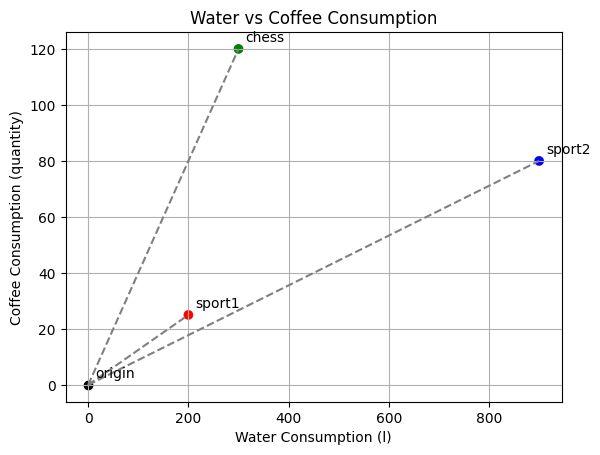

In [3]:
water = [200, 900, 300]
coffe = [25, 80, 120]
labels = ['sport1', 'sport2', 'chess']

plt.scatter(x=water, y=coffe, c=['red', 'blue', 'green'])
plt.scatter(0, 0, c='black')

# annotate the points
plt.annotate('origin', (0, 0), textcoords="offset points", xytext=(5,5))
for x, y, label in zip(water, coffe, labels):
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(5,5))
    
# line from origin to each point
for x, y in zip(water, coffe):
    plt.plot([0, x], [0, y], linestyle='--', color='gray')

plt.xlabel('Water Consumption (l)')
plt.ylabel('Coffee Consumption (quantity)')
plt.title('Water vs Coffee Consumption')
plt.grid()
plt.show()

In [4]:
points = list(zip(water, coffe))
pairs = list(itertools.combinations(range(len(points)), 2)) # combinations of indices

print("Euclidean distance between points:\n")
for i, j in pairs:
    dist = distance.euclidean(points[i], points[j])
    print(f"{labels[i]} - {labels[j]}: {dist}")
    
print("\n\nCosine distance between points:\n")
for i, j in pairs:
    dist = distance.cosine(points[i], points[j])
    print(f"{labels[i]} - {labels[j]}: {dist}")

Euclidean distance between points:

sport1 - sport2: 702.1573897638619
sport1 - chess: 137.93114224133723
sport2 - chess: 601.3318551349163


Cosine distance between points:

sport1 - sport2: 0.0006371456524505437
sport1 - chess: 0.03262777661975469
sport2 - chess: 0.04228691809056362


sport1 - chess are closest in the euclidean distance.

sport1 - sport2 are closest in cosine distance.

### Zadanie 2

#### A)

Mamy dane dotyczące kilku parków narodowych. Chcielibyśmy wykorzystać poznane w poprzednim zadaniu miary podobieństwa w celu odnalezienia najbardziej podobnych parków na podstawie pewnych szacunkowych pomiarów liczby drzew (iglastych i liściastych) oraz populacji kilku gatunków zwierząt. 

  

1. Dla każdej pary parków oblicz odległość Euklidesową i kosinusową. 
2. Wskaż parę najbardziej podobnych parków (dla każdej metryki osobno).  
4. Na podstawie uzyskanych wyników odpowiedz na pytanie która miara lepiej oddaje podobieństwo między parkami? Uzasadnij swoją opinię.
5. Znajdź park najbardziej podobny do Tatrzańskiego Parku Narodowego? 

Szacunkowe dane:

| Nazwa                                       | Liczba drzew iglastych | Liczba drzew liściastych | Liczba dzików | Liczba wilków | Liczba niedźwiedzi | Liczba jeleni |
| ---                                         | ---      | ---    |--- |--- | --- | ---  |
|Tatrzański Park Narodowy (Polska)            |   1000000|  200000|  90|  75|   50|  1200|
|Białowieski Park Narodowy (Polska)           |    250000| 1100000| 250|  40|    0|  1000|
|Yellowstone National Park (Stany Zjednoczone)|  30000000| 1000000|   0| 120| 1200| 30000|
|Banff National Park (Kanada)                 | 110000000| 7000000|   0|  40|  120|  5000|
|Nadbajkalski Park Narodowy (Rosja)           |   8000000| 2100000| 700| 550|  225|  6000|

#### B)

Co można zrobić, aby odległość Euklidesa zwracała wyniki podobne do kosinusowej? Wykonaj zadanie ponownie uzyskując inne (być może "lepsze") wyniki dla metryki Euklidesa niż w podzadaniu A.

In [17]:
parks = [
    [1_000_000, 200_000, 90, 75, 50, 1200],
    [250_000, 1_100_000, 250, 40, 0, 1000],      
    [30_000_000, 1_000_000, 0, 120, 1200, 30_000],
    [110_000_000, 7_000_000, 0, 40, 120, 5000],   
    [8_000_000, 2_100_000, 700, 550, 225, 6000]
]

names = [
    "Tatrzański",
    "Białowieski",
    "Yellowstone",
    "Banff",
    "Nadbajkalski"
]

parks = np.array(parks, dtype=np.float64)

# all pairs of parks
pairs = list(itertools.combinations(range(len(parks)), 2))

euclidean_results = []
cosine_results = []

for i, j in pairs:
    d = distance.euclidean(parks[i], parks[j])
    euclidean_results.append(((i, j), d))
    # print(f"{names[i]} - {names[j]}: {d:.2f}")

for i, j in pairs:
    d = distance.cosine(parks[i], parks[j])
    cosine_results.append(((i, j), d))
    # print(f"{names[i]} - {names[j]}: {d:.2f}")
    
    
print("Euclidean distance between parks:\n")
euclidean_results.sort(key = lambda x: x[1])
[print(f"{names[i]} - {names[j]}: {d:.6f}") for (i,j), d in euclidean_results]


print("\nCosine distance between parks:\n")
cosine_results.sort(key = lambda x: x[1])
[print(f"{names[i]} - {names[j]}: {d:.6f}") for (i,j), d in cosine_results]
print()

Euclidean distance between parks:

Tatrzański - Białowieski: 1171537.480973
Tatrzański - Nadbajkalski: 7253276.753878
Białowieski - Nadbajkalski: 7814251.436524
Yellowstone - Nadbajkalski: 22027495.945421
Tatrzański - Yellowstone: 29011046.702465
Białowieski - Yellowstone: 29750182.226482
Yellowstone - Banff: 80224688.383145
Banff - Nadbajkalski: 102117628.261535
Tatrzański - Banff: 109211904.179234
Białowieski - Banff: 109908473.358868

Cosine distance between parks:

Yellowstone - Banff: 0.000457
Tatrzański - Nadbajkalski: 0.001759
Tatrzański - Banff: 0.008945
Tatrzański - Yellowstone: 0.013430
Banff - Nadbajkalski: 0.018597
Yellowstone - Nadbajkalski: 0.024847
Białowieski - Nadbajkalski: 0.538056
Tatrzański - Białowieski: 0.591443
Białowieski - Banff: 0.716898
Białowieski - Yellowstone: 0.746015



In [6]:
# better results for euclidean - normalize the data
scaler = MinMaxScaler()
parks_norm = scaler.fit_transform(parks)

parks_norm

array([[0.00683371, 0.        , 0.12857143, 0.06862745, 0.04166667,
        0.00689655],
       [0.        , 0.13235294, 0.35714286, 0.        , 0.        ,
        0.        ],
       [0.27107062, 0.11764706, 0.        , 0.15686275, 1.        ,
        1.        ],
       [1.        , 1.        , 0.        , 0.        , 0.1       ,
        0.13793103],
       [0.07061503, 0.27941176, 1.        , 1.        , 0.1875    ,
        0.17241379]])

In [18]:
euclidean_results_norm = []

for i, j in pairs:
    d = distance.euclidean(parks_norm[i], parks_norm[j])
    euclidean_results_norm.append(((i, j), d))
    
print("Euclidean distance between parks:\n")
euclidean_results.sort()
[print(f"{names[i]} - {names[j]}: {d:.6f}") for (i,j), d in euclidean_results]
    
print("Euclidean normalize distance between parks:\n")
euclidean_results_norm.sort(key = lambda x: x[1])
[print(f"{names[i]} - {names[j]}: {d:.6f}") for (i,j), d in euclidean_results_norm]


print("\nCosine distance between parks:\n")
cosine_results.sort(key = lambda x: x[1])
[print(f"{names[i]} - {names[j]}: {d:.6f}") for (i,j), d in cosine_results]
print()

Euclidean distance between parks:

Tatrzański - Białowieski: 1171537.480973
Tatrzański - Yellowstone: 29011046.702465
Tatrzański - Banff: 109211904.179234
Tatrzański - Nadbajkalski: 7253276.753878
Białowieski - Yellowstone: 29750182.226482
Białowieski - Banff: 109908473.358868
Białowieski - Nadbajkalski: 7814251.436524
Yellowstone - Banff: 80224688.383145
Yellowstone - Nadbajkalski: 22027495.945421
Banff - Nadbajkalski: 102117628.261535
Euclidean normalize distance between parks:

Tatrzański - Białowieski: 0.276229
Białowieski - Nadbajkalski: 1.226687
Tatrzański - Nadbajkalski: 1.325762
Białowieski - Banff: 1.381806
Tatrzański - Yellowstone: 1.418674
Tatrzański - Banff: 1.424146
Białowieski - Yellowstone: 1.491929
Yellowstone - Banff: 1.699310
Yellowstone - Nadbajkalski: 1.766999
Banff - Nadbajkalski: 1.841697

Cosine distance between parks:

Yellowstone - Banff: 0.000457
Tatrzański - Nadbajkalski: 0.001759
Tatrzański - Banff: 0.008945
Tatrzański - Yellowstone: 0.013430
Banff - Nadbajk

### Zadanie 3 

Plik `glosowanie.csv` zawiera dane o posłach, którzy głosowali **ZA** w głosowaniach parlamentarnych. Plik zawiera następujące informacje:
- imię i nazwisko posła,
- przynależność do klubu poselskiego,
- numer posiedzenia i numer głosowania.

Zakres danych obejmuje głosowania od 3. do 35. posiedzenia**.

1. Przekształć dane do formy, w której każdy klub jest reprezentowany jako wektor.
2. Oblicz miarę podobieństwa między klubami.
3. Wskaż:
   - parę klubów głosujących najbardziej podobnie,
   - parę klubów głosujących najmniej podobnie,
   - klub, który głosuje najbardziej odmiennie od pozostałych (tj. ma największą sumę odległości do wszystkich innych klubów).


> Uwaga! Uwzględnij, że niektóre kluby poselskie zmieniły nazwę (zgrupuj je).
 
> Możesz postarać się usunąć mało istotne głosowania np. "Wniosek o przerwę"

In [2]:
votes = pd.read_csv('glosowanie.csv')
votes

,id,numerPosiedzenia,numerGlosowania,imie,nazwisko,glos,klub,temat
0,1,1,3,Andrzej,Adamczyk,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...
1,1,1,3,Waldemar,Andzel,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...
2,1,1,3,Dorota,Arciszewska-Mielewczyk,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...
3,1,1,3,Jan,Ardanowski,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...
4,1,1,3,Iwona,Arent,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...
...,...,...,...,...,...,...,...,...
379546,1699,35,53,Jarosław,Krajewski,YES,PiS,głosowanie nad przyjęciem wniosku z druku.
379547,1699,35,53,Bożena,Lisowska,YES,KO,głosowanie nad przyjęciem wniosku z druku.
379548,1699,35,53,Aleksandra,Kot,YES,KO,głosowanie nad przyjęciem wniosku z druku.
379549,1699,35,53,Rafał,Romanowski,YES,PiS,głosowanie nad przyjęciem wniosku z druku.


In [3]:
votes['temat'].unique()

array(['Głosowanie nad kandydaturą Posła Krzysztofa Bosaka na stanowisko Wicemarszałka Sejmu',
       'Głosowanie nad kandydaturą Posła Włodzimierza Czarzastego na stanowisko Wicemarszałka Sejmu',
       'Głosowanie nad kandydaturą Poseł Doroty Niedzieli na stanowisko Wicemarszałka Sejmu',
       'Głosowanie nad kandydaturą Poseł Moniki Wielichowskiej na stanowisko Wicemarszałka Sejmu',
       'Głosowanie nad kandydaturą Poseł Elżbiety Witek na stanowisko Wicemarszałka Sejmu',
       'Głosowanie nad kandydaturą Posła Piotra Zgorzelskiego na stanowisko Wicemarszałka Sejmu',
       'głosowanie nad przyjęciem wniosku z druku.',
       'głosowanie nad całością projektu.',
       'głosowanie nad przyjęciem propozycji wysłuchania 3-minutowych oświadczeń w imieniu klubów i koła ',
       'wyrażenie zgody na skrócenie terminu określonego w art. 30 ust. 4 regulaminu Sejmu',
       'wniosek o skrócenie terminu, o którym mowa w art. 37 ust. 4 regulaminu Sejmu',
       'Wniosek o przerwę', 'Wniose

In [4]:
print(votes.shape)
votes = votes[votes['temat'] != 'Wniosek o przerwę'].copy()
print(votes.shape)

(379551, 8)
(365685, 8)


In [5]:
votes['klub'].unique()

array(['PiS', 'PSL', 'Konfederacja', 'Polska2050', 'KO', 'Nowa_Lewica',
       'PSL-TD', 'Polska2050-TD', 'Lewica', 'Kukiz15', 'niez.', 'Razem',
       'Republikanie'], dtype=object)

In [6]:
klub_map = {
    'PiS': 'PiS',
    'KO': 'KO',
    'Polska2050': 'Polska2050-TD',
    'Polska2050-TD': 'Polska2050-TD',
    'PSL': 'PSL-TD',
    'PSL-TD': 'PSL-TD',
    'Nowa_Lewica': 'Lewica',
    'Lewica': 'Lewica',
    'Razem': 'Lewica',
    'Konfederacja': 'Konfederacja',
    'Kukiz15': 'Kukiz15',
    'Republikanie': 'Kukiz15',
    'niez.': 'niez.'
}

votes['klub_zgrup'] = votes['klub'].map(klub_map)

In [7]:
votes['klub_zgrup'].unique()

array(['PiS', 'PSL-TD', 'Konfederacja', 'Polska2050-TD', 'KO', 'Lewica',
       'Kukiz15', 'niez.'], dtype=object)

In [8]:
votes['glos'].unique()

array(['YES'], dtype=object)

In [9]:
votes['glos_id'] = votes['numerPosiedzenia'].astype(str) + '_' + votes['numerGlosowania'].astype(str)
votes

,id,numerPosiedzenia,numerGlosowania,imie,nazwisko,glos,klub,temat,klub_zgrup,glos_id
0,1,1,3,Andrzej,Adamczyk,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...,PiS,1_3
1,1,1,3,Waldemar,Andzel,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...,PiS,1_3
2,1,1,3,Dorota,Arciszewska-Mielewczyk,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...,PiS,1_3
3,1,1,3,Jan,Ardanowski,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...,PiS,1_3
4,1,1,3,Iwona,Arent,YES,PiS,Głosowanie nad kandydaturą Posła Krzysztofa Bo...,PiS,1_3
...,...,...,...,...,...,...,...,...,...,...
379546,1699,35,53,Jarosław,Krajewski,YES,PiS,głosowanie nad przyjęciem wniosku z druku.,PiS,35_53
379547,1699,35,53,Bożena,Lisowska,YES,KO,głosowanie nad przyjęciem wniosku z druku.,KO,35_53
379548,1699,35,53,Aleksandra,Kot,YES,KO,głosowanie nad przyjęciem wniosku z druku.,KO,35_53
379549,1699,35,53,Rafał,Romanowski,YES,PiS,głosowanie nad przyjęciem wniosku z druku.,PiS,35_53


In [10]:
vote_matrix = pd.pivot_table(votes, index='klub_zgrup', columns='glos_id', values='nazwisko', aggfunc='count', fill_value=0)
# vote_matrix = (vote_matrix > 0).astype(int)
vote_matrix

glos_id,10_1,10_10,10_11,10_12,10_13,10_14,10_15,10_16,10_17,10_18,...,9_35,9_36,9_37,9_38,9_39,9_40,9_6,9_7,9_8,9_9
klub_zgrup,,,,,,,,,,,,,,,,,,,,,
KO,116,149,149,1,149,1,149,0,0,0,...,153,152,152,153,153,149,152,0,153,0
Konfederacja,0,17,0,16,0,17,0,17,17,17,...,0,0,0,0,0,13,14,14,14,14
Kukiz15,0,2,0,2,0,2,2,2,2,2,...,0,0,0,0,0,3,3,3,3,3
Lewica,23,25,25,0,25,0,25,0,0,0,...,25,25,25,25,25,25,26,0,26,0
PSL-TD,25,28,28,0,28,0,28,0,0,0,...,31,32,29,31,29,31,31,0,32,0
PiS,0,174,0,168,2,174,173,174,174,174,...,0,0,0,0,1,170,180,182,182,181
Polska2050-TD,28,31,31,0,31,0,31,0,0,0,...,31,31,32,31,31,29,32,0,32,0
niez.,1,2,1,1,1,1,2,1,1,1,...,1,1,1,1,2,2,2,1,2,1


In [11]:
results_cosine = []
results_euclidean = []
for a, b in combinations(vote_matrix.index.tolist(), 2):
    votes1 = vote_matrix.loc[a].values
    votes2 = vote_matrix.loc[b].values
    results_cosine.append(((a,b), distance.cosine(votes1, votes2)))
    results_euclidean.append(((a,b), distance.euclidean(votes1, votes2)))

In [12]:
most_similar_cosine = min(results_cosine, key = lambda x: x[1])
most_similar_euclidean = min(results_euclidean, key = lambda x: x[1])
least_similar_cosine = max(results_cosine, key = lambda x: x[1])
lest_similar_euclidean = max(results_euclidean, key = lambda x: x[1])

print(f"Most similar parties (cosine): {most_similar_cosine}")
print(f"Least similar praties: (cosine): {least_similar_cosine}")
print()
print(f"Most similar parties (euclidean): {most_similar_euclidean}")
print(f"Least similar praties: (euclidean): {lest_similar_euclidean}")

Most similar parties (cosine): (('KO', 'PSL-TD'), np.float64(0.014720323860028417))
Least similar praties: (cosine): (('Konfederacja', 'Lewica'), np.float64(0.61514370217216))

Most similar parties (euclidean): (('Kukiz15', 'niez.'), np.float64(82.09750300709517))
Least similar praties: (euclidean): (('PiS', 'niez.'), np.float64(5443.908981605038))


In [13]:
# most different from the others
sum_dist = {c: 0 for c in vote_matrix.index.tolist()}
for (a, b), dist in results_cosine:
    sum_dist[a] += dist
    sum_dist[b] += dist
most_diff_cos = max(sum_dist.items(), key=lambda x: x[1])

sum_dist = {c: 0 for c in vote_matrix.index.tolist()}
for (a, b), dist in results_euclidean:
    sum_dist[a] += dist
    sum_dist[b] += dist
most_diff_euc = max(sum_dist.items(), key=lambda x: x[1])


print("Most different club (cosine):", most_diff_cos)
print("Most different club (euclidean):", most_diff_euc)

Most different club (cosine): ('Konfederacja', np.float64(3.690733549179973))
Most different club (euclidean): ('PiS', np.float64(36732.667053248995))
